### Discrete Divergence Formulation for Horizontal Force Balance

In this section, we compute the **horizontal force balance** within a 2-D Stokes model using the **discrete divergence form** of the momentum equation:

\begin{equation}
\frac{\partial \sigma_{xx}}{\partial x} + \frac{\partial \sigma_{xz}}{\partial z} = 0
\end{equation}

#### Stress mapping and grid structure
The model uses a **staggered finite-difference grid**:
- **Normal stresses** (σₓₓ) and **pressure** are defined at **cell centers**.
- **Shear stresses** (σₓ𝓏) are defined at **cell vertices**.
- The grid spacing is uniform in both x and z.

For the discrete divergence approach, we first **map all stress components to cell-face centers**:
- σxx → vertical faces (x-faces)
- σzz → horizontal faces (z-faces)

This mapping ensures that each stress component acts naturally on the boundaries of the control volume (cell), consistent with the finite-volume interpretation of equilibrium.

#### Discrete divergence and residual closure
We then compute the **discrete divergence** of the stress tensor over each cell:
\begin{equation}
R_{ij} = \frac{\sigma_{xx}(x_{j+1/2}) - \sigma_{xx}(x_{j-1/2})}{\Delta x}
       + \frac{\sigma_{xz}(z_{i+1/2}) - \sigma_{xz}(z_{i-1/2})}{\Delta z}
\end{equation}

Integrating this residual with depth gives the **cumulative horizontal force imbalance** (in Pa·m or TN/m) for each column.

If the model satisfies static equilibrium exactly, the integrated residual should close to zero at all depths.  
In practice, small non-zero values reveal where **numerical truncation errors** or **rheological contrasts** lead to incomplete force balance.

#### Purpose of the analysis
This workflow:
1. Maps stresses from the staggered grid to face centers.
2. Evaluates the discrete divergence per cell.
3. Vertically integrates the residuals to visualize force balance closure with depth.
4. Optionally integrates horizontally to assess cumulative forces relative to the trench.

This provides a robust, grid-consistent measure of how well the numerical solution satisfies equilibrium at all scales.




#### Example: integrating across cells

Suppose we integrate horizontally across three cells with indices i = 0, 1, 2.

* There are four vertical faces (edges 0–3).
* The discrete divergence form integrates the stress derivatives within each cell.
* The result is plotted at cell centers (i = 0, 1, 2).

In contrast, the traction (boundary) form would directly compare tractions at faces 0 and 3, returning three values (one per cell) but never computing explicit derivatives.

In both formulations, the physically meaningful comparison point for plotting is always the cell center, because each cumulative integral represents the net horizontal force balance associated with that control volume

In [1]:
#import pyvista as pv
import numpy as np
import glob
import natsort
import matplotlib.pyplot as plt
import h5py
from scipy.integrate import trapz, cumtrapz
from scipy.ndimage import gaussian_filter

plt.rcParams.update({
    "mathtext.fontset": "cm",  
    "font.family": "serif",     
})

from helpers import *

In [75]:
data_dir = '../model_output_data/MD7_ref_model/'

In [42]:
# ---------------------------------------------------------------------
# PHYSICAL CONSTANTS AND DOMAIN SETUP
# ---------------------------------------------------------------------
delrho     = 3250
g          = 9.81
s2my       = 3.1436e13
xmin       = -1600e3
xmax       = 1600e3
#swap the z coordinate to z positive down
zmin       = -20e3
zmax       = 660e3
#integration depth limit
z_c_depth  = 100e3

## Load data

In [43]:
#Load one of the HDF5 files to get some information on the grid
h5_fnames = natsort.natsorted(glob.glob(data_dir  + '*.h5')) 

# Loop through all .h5 files
for index, h5_fname in enumerate(h5_fnames):
    # Open the file using a context manager
    with h5py.File(h5_fname, 'r') as h5file:
        # Extract the time value from the file
        time = h5file["/Model/Params"][0].astype(int) / s2my
        # Print the file index and formatted time
        print(f"File index: {index}, Time step: {time:.1f} Myrs")

File index: 0, Time step: 0.0 Myrs
File index: 1, Time step: 0.1 Myrs
File index: 2, Time step: 1.3 Myrs
File index: 3, Time step: 2.8 Myrs
File index: 4, Time step: 4.2 Myrs
File index: 5, Time step: 6.0 Myrs


In [26]:
# ---------------------------------------------------------------------
# Select model snapshot and open corresponding HDF5 file
# ---------------------------------------------------------------------

# Choose which output file to analyse.
# (Negative indices count from the end; e.g. -1 = latest timestep)
file_index_number = -1

# Open the selected model output
h5file = h5py.File(h5_fnames[file_index_number], 'r')

# Access global model parameters
data = h5file['/Model/Params']

# Extract and convert model time from seconds to Myr
time = h5file['/Model/Params'][0].astype(int) / s2my

print(f" Time step: {time:.1f} Myr")

In [44]:

# ---------------------------------------------------------------------
# Mesh setup and geometric parameters
# ---------------------------------------------------------------------

# Nx, Nz = number of VERTICES in the x and z directions
# (each grid cell is bounded by 2 vertices ⇒ there are Nx−1 and Nz−1 cell centers)
Nx  = data[3].astype(int)
Nz  = data[4].astype(int)

# Nominal grid spacing (m)
# use ceil to avoid small floating-point rounding errors when reconstructing domain
dx  = np.ceil((xmax - xmin) / (Nx - 1))   # horizontal spacing (m)
dz  = np.ceil((zmax - zmin) / (Nz - 1))   # vertical spacing (m)

# Vertex coordinates (boundaries of cells)
vxpts = np.linspace(xmin, xmax, Nx)       # x-coordinates of vertices
vzpts = np.linspace(zmin, zmax, Nz)       # z-coordinates of vertices

# Cell-center coordinates (midpoints between adjacent vertices)
cxpts = 0.5 * (vxpts[1:] + vxpts[:-1])    # x-centers of cells  → length Nx−1
czpts = 0.5 * (vzpts[1:] + vzpts[:-1])    # z-centers of cells  → length Nz−1

# ---------------------------------------------------------------------
# Indices for reference depths / limits
# ---------------------------------------------------------------------

# Index of the vertical vertex just beyond the integration limit z_c_depth
# (used for selecting the deepest vertical integration slice)
#vbase_indx = np.argmin(np.abs(vzpts - z_c_depth))
vbase_indx = vertical_index(z_c_depth, vzpts)

# Index of the cell center nearest to z_c_depth
# (used when plotting or sampling quantities defined on cell centers)
cbase_indx = vertical_index(z_c_depth, czpts)

 Time step: 6.0 Myrs


In [46]:
# ---------------------------------------------------------------------
# Load and prepare topography array from HDF5 file
# ---------------------------------------------------------------------

# Attempt to read "x" and "z" coordinates for surface topography.
# Some model outputs store these under 'x_mark'/'z_mark' instead of 'x'/'z'.
try:
    topo_ = np.column_stack((
        h5file["/Topo"]["x_mark"][:],
        h5file["/Topo"]["z_mark"][:]
    ))
except KeyError:
    topo_ = np.column_stack((
        h5file["/Topo"]["x"][:],
        h5file["/Topo"]["z"][:]
    ))

# Initialise a 3-column array for convenience.
# Columns: [x, z, (reserved placeholder for later derived quantity)]
new_array = np.zeros((topo_.shape[0], 3))
new_array[:, :2] = topo_

# Sort rows by x-coordinate to ensure monotonic topography profile
topo = new_array[np.argsort(new_array[:, 0])]


# ---------------------------------------------------------------------
# Identify trench position and reference index
# ---------------------------------------------------------------------

# The trench is defined as the x-position of the topographic minimum
tloc = topo[:, 0][np.argmin(topo[:, 1])]

# Find the first mesh vertex located to the right of the trench
tindx = np.argmax(cxpts > tloc)



## Calculate the cumulative horizontal force residual for an column of cells

In [66]:

myindx, myxloc = horizontal_index(tloc + 200e3, vxpts)


#This function computes the discrete vertical cumulative residual of the horizontal force balance for a single column 
#i in the stress grid, using a finite-volume (divergence form) approach.
#It first maps the normal stress \sigma_{xx} to vertical faces and computes its horizontal derivative 
#\partial_x \sigma_{xx} across the column.
#Then it computes the vertical derivative \partial_z \tau_{xz} of the shear stress evaluated at horizontal faces.
#The sum of these two terms gives the discrete divergence of stress 
#Finally, this residual is vertically integrated from the surface downward, 
#giving the cumulative imbalance \int (\partial_x \sigma_{xx} + \partial_z \tau_{xz}) \, dz as a function of depth.

zcuts, Rdiv_cum = residual_divergence_column(myindx, sig_xx_grid, tau_xz_grid, vzpts, dx, dz)

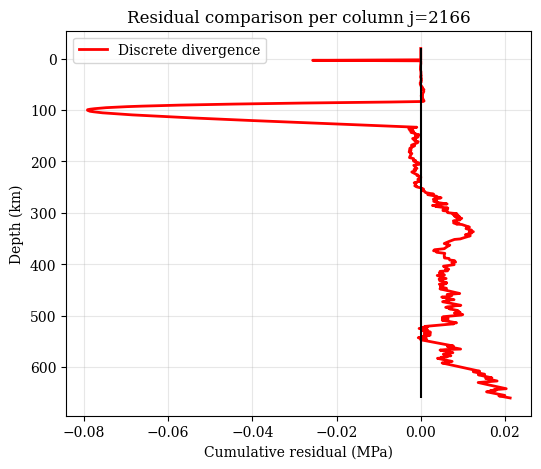

In [67]:

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(Rdiv_cum/1e6, czpts/1e3, 'r-', lw=2, label='Discrete divergence')
ax.invert_yaxis()
ax.set_xlabel('Cumulative residual (MPa)')
ax.set_ylabel('Depth (km)')
ax.set_title(f'Residual comparison per column j={myindx}')
ax.legend()
ax.grid(True, alpha=0.3)
ax.vlines(0, -20, 660, color='k')
plt.show()

#print("max |Δ| =", np.max(np.abs(Rdiv_cum - Rtrac_cum)))

In [69]:
#This function computes the discrete divergence of stress over the entire 2-D domain using a vectorized (grid-wide) 
#finite-volume formulation.
#It produces the same result as running residual_divergence_column for every column, 
#but does so efficiently across the whole grid.

zcuts, R_cum_div_grid = residual_divergence_grid(sig_xx_grid, tau_xz_grid, vzpts, dx, dz)


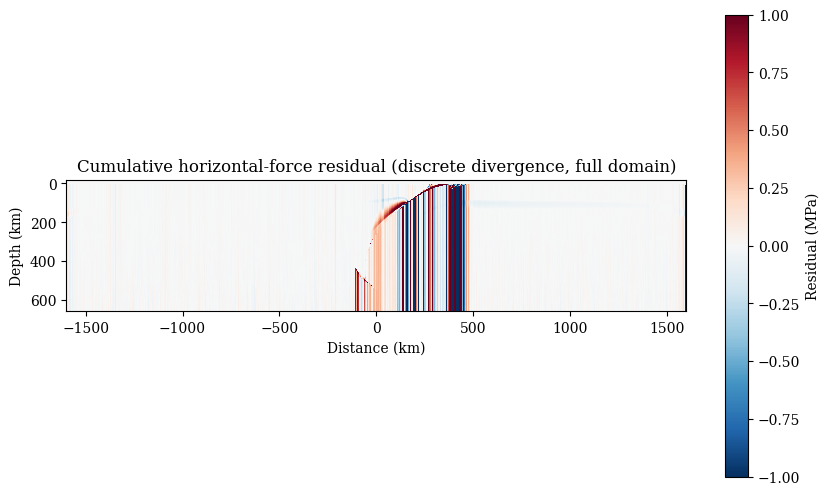

In [70]:
# x,z coordinates in km
cx = 0.5 * (vxpts[1:] + vxpts[:-1])
x_km = cx / 1e3
z_km = zcuts / 1e3

# --- plot full domain cumulative residuals (MPa) ---
fig, ax = plt.subplots(figsize=(10,6))
im = ax.pcolormesh(x_km, z_km, (R_cum_div_grid)/1e6, cmap='RdBu_r',vmin =-1, vmax=1, shading='auto')
ax.invert_yaxis()
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Depth (km)')
ax.set_title('Cumulative horizontal-force residual (discrete divergence, full domain)')
fig.colorbar(im, ax=ax, label='Residual (MPa)')
ax.set_aspect(1)

plt.show()

## Now compute the horizontal integral, effective the net force due to the residual

In [71]:

horizontal_cumulative_residual = np.cumsum(R_cum_div_grid* dx, axis=1)

## And plot as a fucntion of depth, to assess effect of intrgaration depth

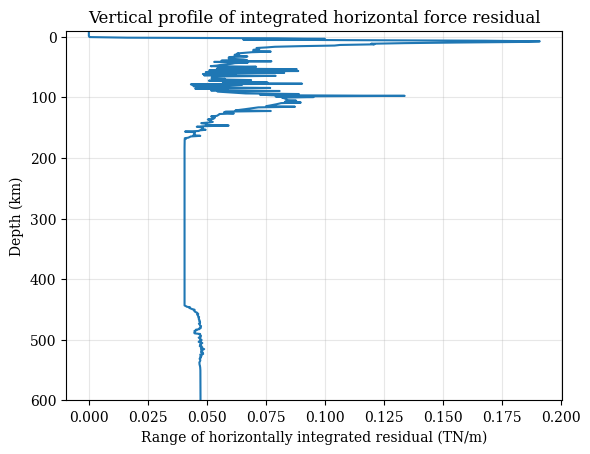

In [72]:
fig, ax = plt.subplots()

ax.plot(1e-12*(np.max(horizontal_cumulative_residual, axis = 1) - np.min(horizontal_cumulative_residual, axis = 1)),
        1e-3*czpts)

ax.set_ylim(600, -10)

# --- Axis labels and title ---
ax.set_xlabel("Range of horizontally integrated residual (TN/m)")
ax.set_ylabel("Depth (km)")
ax.set_title("Vertical profile of integrated horizontal force residual")

# --- Grid and styling (optional) ---
ax.grid(True, alpha=0.3)

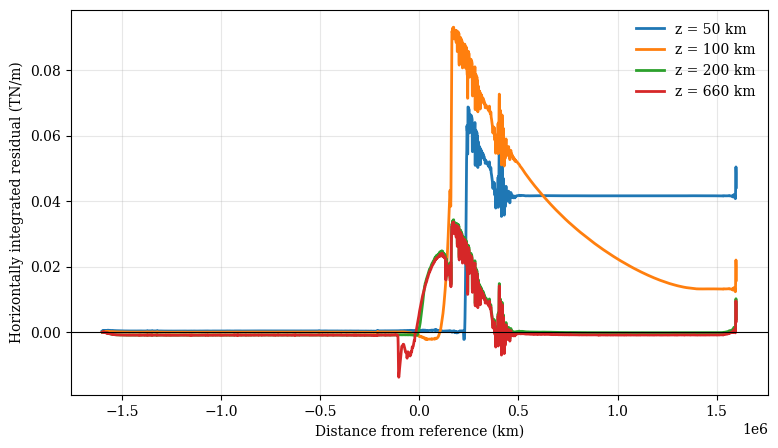

In [73]:
# Example plot at selected depths
fig, ax = plt.subplots(figsize=(9,5))
for depth in [50e3, 100e3, 200e3, 660e3]:
    iz = np.argmin(np.abs(vzpts - depth)) - 1
    ax.plot(cxpts, 1e-12*horizontal_cumulative_residual[iz, :], lw=2, label=f"z = {depth/1e3:.0f} km")

ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Distance from reference (km)')
ax.set_ylabel('Horizontally integrated residual (TN/m)')
ax.set_xlim()
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
plt.show()

## Plot  mesh mappings

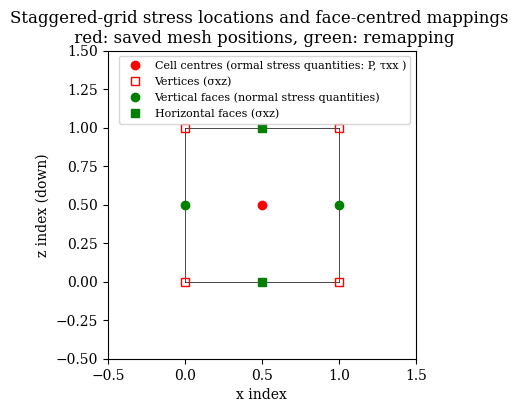

In [74]:
# Simple 4×3 mesh (3 cells wide, 2 cells tall)
# Simple 4×3 mesh (3 cells wide, 2 cells tall)
Nx, Nz = 2, 2
vx = np.arange(Nx)              # vertex x positions
vz = np.arange(Nz)              # vertex z positions
cx = 0.5*(vx[:-1] + vx[1:])     # cell-center x
cz = 0.5*(vz[:-1] + vz[1:])     # cell-center z

fig, ax = plt.subplots(figsize=(6,4))

# Plot cell boundaries
for x in vx:
    ax.plot([x, x], [vz[0], vz[-1]], 'k-', lw=0.5)
for z in vz:
    ax.plot([vx[0], vx[-1]], [z, z], 'k-', lw=0.5)

# Plot cell centers (pressure, σxx, σzz)
for x in cx:
    for z in cz:
        ax.plot(x, z, 'ro', label='Cell centres (ormal stress quantities: P, τxx )' if (x==cx[0] and z==cz[0]) else "")

# Plot vertices (σxz)
for x in vx:
    for z in vz:
        ax.plot(x, z, 'rs', mfc='none', label='Vertices (σxz)' if (x==vx[0] and z==vz[0]) else "")

# Plot vertical faces (σxx)
for x in vx:
    for z in cz:
        ax.plot(x, z, 'go', label='Vertical faces (normal stress quantities)' if (x==vx[0] and z==cz[0]) else "")

# Plot horizontal faces (σxz)
for x in cx:
    for z in vz:
        ax.plot(x, z, 'gs', label='Horizontal faces (σxz)' if (x==cx[0] and z==vz[0]) else "")

ax.set_xlim(-0.5, Nx-0.5)
ax.set_ylim(-0.5, Nz-0.5)
ax.set_aspect('equal')
ax.set_xlabel('x index')
ax.set_ylabel('z index (down)')
ax.set_title('Staggered-grid stress locations and face-centred mappings \n red: saved mesh positions, green: remapping')
ax.legend(loc='upper right', fontsize=8)
plt.show()